# Extended Data Figure 5

Environment: env 1

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import pandas as pd
import seaborn as sns
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statannotations.Annotator import Annotator
import matplotlib as mpl
import sys

sys.path.append("../utils")
from utils import prepare_feature_catalog, box_plot_hdp, get_pca_df


c:\Users\ds7014\NYU Langone Health Dropbox\Daniel Sunko\dans_stuff\Visionary-AI-HDP\code\extended_data\../utils\utils.py:793: SyntaxWarning: invalid escape sequence '\c'
  sns.stripplot(df_, x=xval, y=yval,color='black' , marker="$\circ$", alpha = 0.2, edgecolor='k', linewidth=0.6, order = ['HC','PW', 'PEC'], jitter=0.2, size=4)
c:\Users\ds7014\NYU Langone Health Dropbox\Daniel Sunko\dans_stuff\Visionary-AI-HDP\code\extended_data\../utils\utils.py:847: SyntaxWarning: invalid escape sequence '\c'
  sns.stripplot(df_, x=xval, y=yval,color='black' , marker="$\circ$", alpha = 0.2, edgecolor='k', linewidth=0.6, order = ['HC','PW','GHTN','CHTN'], jitter=0.2, size=4)


# load data

In [2]:
# initialize paths

dropbox_path = "C:\\Users\\ds7014\\NYU Langone Health Dropbox\\Daniel Sunko/Shenhav_lab/Visionary_AI"


full_dataset_path = os.path.join(dropbox_path,'code_data/Data/columbia')

cohort_pickles_path = os.path.join(full_dataset_path,'cohort_pickles')

data_name = 'features_all'
results_folder = os.path.join(full_dataset_path,data_name)

control_file = os.path.join(cohort_pickles_path, 'final_hc_20251017.pkl')
clinical_file = os.path.join(full_dataset_path, 'clinical_features_all_20250930.csv')
clean_controls = pd.read_pickle("C:\\Users\\ds7014\\Downloads\\all_hc_pw1-5.pkl")

n_comps = 10

In [3]:
case_file_pec = os.path.join(cohort_pickles_path, 'final_pec_20251017.pkl')
pec_ids = pd.read_pickle(case_file_pec)
pec_ids = [x.lower() for x in pec_ids]
pec_ids = list(set(pec_ids+['cu0776']))

ght_cases = pd.read_pickle(os.path.join(cohort_pickles_path,'ght_cases_20250926.pkl'))
ght_cases = [x.lower() for x in ght_cases]
cht_cases = pd.read_pickle(os.path.join(cohort_pickles_path,'cht_cases_20250926.pkl'))
cht_cases = [x.lower() for x in cht_cases]

In [4]:
pc_pec = prepare_feature_catalog(
    feature_folder=results_folder,
    pre='final_all',
    post='_2025-10-16',
    case_file=case_file_pec,
    control_file=control_file,
    clinical_file=clinical_file,
    id_regex=r"(cu\d{4})",   
)

df_use_pec      = pc_pec["df_use"]
dfs_pec         = pc_pec["dfs"]
ks_dfs_pec      = pc_pec["ks_dfs"]
pca_dfs_pec     = pc_pec["pca_dfs"]
dfs_map_pec     = pc_pec["dfs_map"]
ks_dfs_map_pec  = pc_pec["ks_dfs_map"]
pca_dfs_map_pec = pc_pec["pca_dfs_map"]
dfs_set_pec     = pc_pec["dfs_set"]
ks_dfs_set_pec  = pc_pec["ks_dfs_set"]
pca_dfs_set_pec = pc_pec["pca_dfs_set"]

catalog_pec = {}
catalog_pec.update(pc_pec["dfs_map"])
catalog_pec.update(pc_pec["ks_dfs_map"])
catalog_pec.update(pc_pec["pca_dfs_map"])

dfs_set_pec     = pc_pec["dfs_set"]
ks_dfs_set_pec  = pc_pec["ks_dfs_set"]
pca_dfs_set_pec = pc_pec["pca_dfs_set"]

feature_dicts_all_pec = {
    "dfs":     [fs for fs in dfs_set_pec],
    "ks_dfs":  [fs for fs in ks_dfs_set_pec],
    "pca_dfs": [fs for fs in pca_dfs_set_pec],
}

y_df_pec = pc_pec['df_use'][['id','label']].drop_duplicates()

In [5]:
pw1_stable = pd.read_pickle(os.path.join(cohort_pickles_path, 'rev_strat_hc_pw1_controls_20260403.pkl'))
pw2_stable = pd.read_pickle(os.path.join(cohort_pickles_path, 'rev_strat_hc_pw2_controls_20260403.pkl'))
pw3_stable = pd.read_pickle(os.path.join(cohort_pickles_path, 'rev_strat_hc_pw3_controls_20260403.pkl'))
pw4_stable = pd.read_pickle(os.path.join(cohort_pickles_path, 'rev_strat_hc_pw4_controls_20260403.pkl'))
pw5_stable = pd.read_pickle(os.path.join(cohort_pickles_path, 'rev_strat_hc_pw5_controls_20260403.pkl'))
pw_stable = pw1_stable+pw2_stable+pw3_stable+pw4_stable+pw5_stable

# boxplots

### graph feats

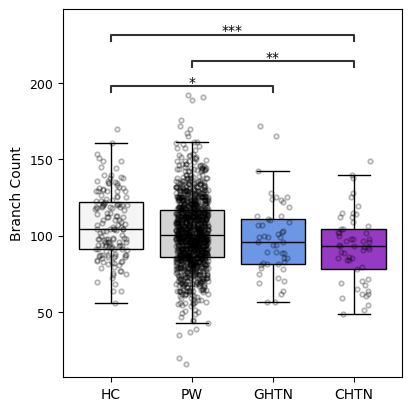

In [7]:
box_plot_hdp(dfs_map_pec['graph_feats[graph_cols]'],{'n_branches':'Branch Count'}, pw_ids=pw_stable,ght_cases=ght_cases,cht_cases=cht_cases,clean_controls=clean_controls)

### nesting number features: Extended Data Fig. 5

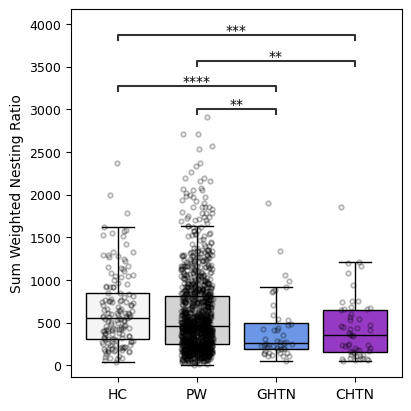

In [8]:
box_plot_hdp(dfs_map_pec['processed_dan_tree_feats[nest_num_feats_dan]'],{'sum_nest_ratios_w_dan':'Sum Weighted Nesting Ratio'}, pw_ids=pw_stable,ght_cases=ght_cases,cht_cases=cht_cases,clean_controls=clean_controls)

### pca tda flooding

In [9]:
pc_temp = get_pca_df(pca_dfs_map_pec['tda_flooding'],n_comps=10)

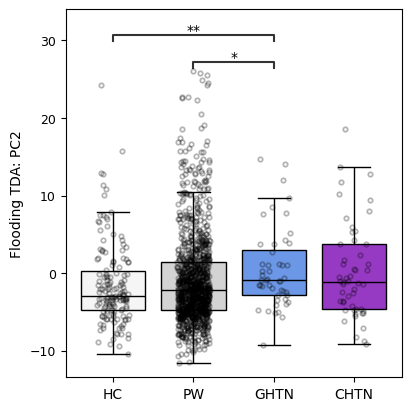

In [10]:
box_plot_hdp(pc_temp,{1:'Flooding TDA: PC2'}, pw_ids=pw_stable,ght_cases=ght_cases,cht_cases=cht_cases,clean_controls=clean_controls)

### pca tda outward

In [11]:
pc_temp = get_pca_df(pca_dfs_map_pec['tda_outward'],n_comps=10, subset_fit=clean_controls+pec_ids)

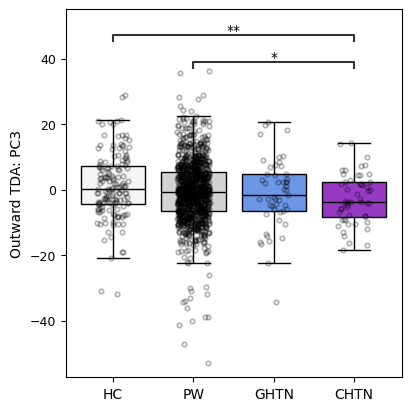

In [12]:
box_plot_hdp(pc_temp,{2:'Outward TDA: PC3'}, pw_ids=pw_stable,ght_cases=ght_cases,cht_cases=cht_cases,clean_controls=clean_controls)